In [1]:
from pathlib import Path
import sys
import importlib
import matplotlib.pyplot as plt

SEQ_DIR = Path('/home/dilay/project2/tw/travelling_waves/tw/fft/mingmin/sequence')
sys.path.insert(0, str(SEQ_DIR))

import mingmin_plot_funcs as twplot


%matplotlib inline


In [2]:
# 改这里控制结果读取目录和 figure 保存目录
RESULT_DIR = Path('/home/dilay/project2/tw/results/mingmin_linux/mingmin_fft')
FIG_DIR = Path('/home/dilay/project2/tw/results/mingmin_linux/mingmin_fft')
twplot.FIG_DIR = FIG_DIR

# intervals.csv（eeg_bad / timing_bad 统计用）所在目录
INTERVALS_DIR = Path('/home/dilay/project2/tw/Data/Mingmin_data/sequency/epoch_autoreject')

# 改这里就可以控制是否做 baseline correction
BASELINE_CORRECT = False
BL0, BL1 = -0.75, -0.25

# valid trial 现在要求 response 和 RT 都不是 NaN。
# 如果想进一步限制反应时，比如两个 RT 都 <= 1.5s，就改成 MAX_RT = 1.5。
MAX_RT = 1.55

# 控制去除 trial 的方式：
# - EXCLUDE_TIMING_ISSUE=True 会去掉 has_timing_issue 的 trial
# - EXCLUDE_BAD_EPOCH=True    会去掉 is_bad_epoch（EEG bad）的 trial
# 两个都 True 就是两种都去掉；两个都 False 就是都不去掉。
EXCLUDE_TIMING_ISSUE = True
EXCLUDE_BAD_EPOCH = True

# 改这里控制图的显示范围
TF_VABS = 0.3

# 指定要画的 measure：'fw' / 'bw' / 'ratio'，或列表如 ['fw', 'ratio']，或 None（全部）
MEASURES = ['fw','bw']

# 11 条线平均 TW power 默认用所有 electrode lines；如果只想选部分 line，在这里填 index。
LINE_IDX = None

# Contra/ipsi line selection for response-hand aligned plots.
# After alignment: C1-C5 are contralateral lines, I1-I5 are ipsilateral lines, M is midline.
CONTRA_LINES = ['C5','C4','C3', 'C2', 'C1']
IPSI_LINES   = ['I1', 'I2', 'I3', 'I4','I5']
LINE_KW = dict(contra_idx=CONTRA_LINES, ipsi_idx=IPSI_LINES)

# 打包成 kwargs，方便传给下面各个 plot 函数
TRIAL_CLEAN_KW = dict(exclude_timing_issue=EXCLUDE_TIMING_ISSUE, exclude_bad_epoch=EXCLUDE_BAD_EPOCH)

print('Aligned line order:', twplot.FLIPPED_LINE_NAMES)
print('Using contra/ipsi indices:', {k: twplot.resolve_line_idx(v, []) for k, v in LINE_KW.items()})

Aligned line order: ['C5', 'C4', 'C3', 'C2', 'C1', 'M', 'I1', 'I2', 'I3', 'I4', 'I5']
Using contra/ipsi indices: {'contra_idx': [0, 1, 2, 3, 4], 'ipsi_idx': [6, 7, 8, 9, 10]}


In [3]:
by_subj, subj_ids = twplot.load_results(RESULT_DIR)

EXCLUDE_SUBJECTS = {}
subj_ids = [s for s in subj_ids if s not in EXCLUDE_SUBJECTS]

print(f'Loaded {sum(len(v) for v in by_subj.values())} session files')
print(f'Excluded subjects: {sorted(EXCLUDE_SUBJECTS)}')
print(f'Using subjects: {subj_ids}')
print(f'N subjects: {len(subj_ids)}')
print({subj: sorted(by_subj[subj].keys()) for subj in subj_ids})

Loaded 116 session files
Excluded subjects: []
Using subjects: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
N subjects: 29
{2: ['1.', '2.', '3.', '4.'], 3: ['1.', '2.', '3.', '4.'], 4: ['1.', '2.', '3.', '4.'], 5: ['1.', '2.', '3.', '4.'], 6: ['1.', '2.', '3.', '4.'], 7: ['1.', '2.', '3.', '4.'], 8: ['1.', '2.', '3.', '4.'], 9: ['1.', '2.', '3.', '4.'], 10: ['1.', '2.', '3.', '4.'], 11: ['1.', '2.', '3.', '4.'], 12: ['1.', '2.', '3.', '4.'], 13: ['1.', '2.', '3.', '4.'], 14: ['1.', '2.', '3.', '4.'], 15: ['1.', '2.', '3.', '4.'], 16: ['1.', '2.', '3.', '4.'], 17: ['1.', '2.', '3.', '4.'], 18: ['1.', '2.', '3.', '4.'], 19: ['1.', '2.', '3.', '4.'], 20: ['1.', '2.', '3.', '4.'], 23: ['1.', '2.', '3.', '4.'], 24: ['1.', '2.', '3.', '4.'], 25: ['1.', '2.', '3.', '4.'], 26: ['1.', '2.', '3.', '4.'], 27: ['1.', '2.', '3.', '4.'], 28: ['1.', '2.', '3.', '4.'], 29: ['1.', '2.', '3.', '4.'], 30: ['1.', '2.', '3.', '4.'], 31: ['1.',

In [4]:
twplot.print_trial_summary(by_subj, subj_ids, rt_type='early', max_rt=MAX_RT)

Subject trial counts after EEG bad + timing bad + RT (early, max_rt=1.55) exclusions
subj	orig	kept	removed	removed%	eeg_bad	eeg_bad%	timing_bad	timing_bad%	rt_bad	rt_bad%	total_excl	total_excl%	fixed(kept/total)	random(kept/total)	early_rt_mean	late_rt_mean
2	1680	1680	0	0.00%	442	26.31%	261	15.54%	34	2.02%	645	38.39%	617/840	418/840	1.032	0.898
3	1680	1680	0	0.00%	601	35.77%	307	18.27%	27	1.61%	799	47.56%	501/840	380/840	0.820	0.739
4	1680	1680	0	0.00%	106	6.31%	334	19.88%	54	3.21%	458	27.26%	588/840	634/840	1.038	0.794
5	1680	1680	0	0.00%	269	16.01%	309	18.39%	37	2.20%	541	32.20%	597/840	542/840	1.017	0.911
6	1680	1680	0	0.00%	198	11.79%	228	13.57%	20	1.19%	409	24.35%	600/840	671/840	0.982	0.768
7	1680	1680	0	0.00%	613	36.49%	311	18.51%	115	6.85%	842	50.12%	500/840	338/840	1.065	0.898
8	1680	1679	1	0.06%	645	38.39%	295	17.56%	20	1.19%	909	54.11%	476/839	295/840	0.940	0.824
9	1680	1680	0	0.00%	1140	67.86%	316	18.81%	8	0.48%	1332	79.29%	167/840	181/840	0.828	0.759
10	1680	1680	0	0.00%

FW (CONTRA) -- Respond-Hand (early) 2D clusters:
2.00-30.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
FW (IPSI) -- Respond-Hand (early) 2D clusters:
2.00-30.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
FW (MID) -- Respond-Hand (early) 2D clusters:
2.00-30.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/fw_early_hand_tf_contra-ipsi-mid.png


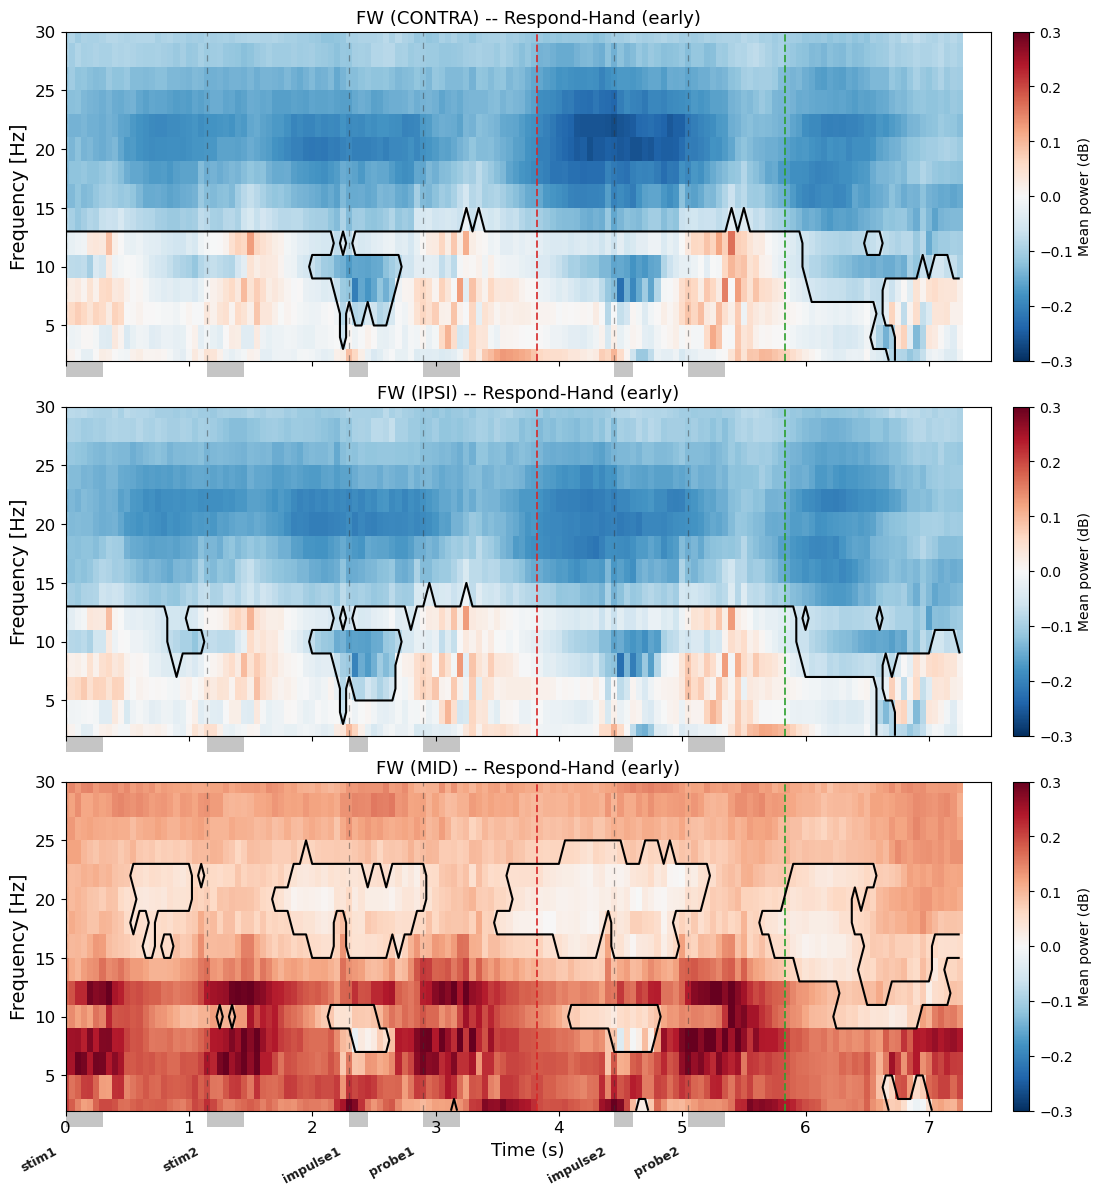

FW (CONTRA-IPSI) -- Respond-Hand (early) 2D clusters:
2.00-4.00 Hz, 3.40-4.35 s, p=0.0124 (significant)
8.00-14.00 Hz, 4.95-5.70 s, p=0.0156 (significant)
14.00-30.00 Hz, 3.85-5.40 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/fw_early_hand_tf.png


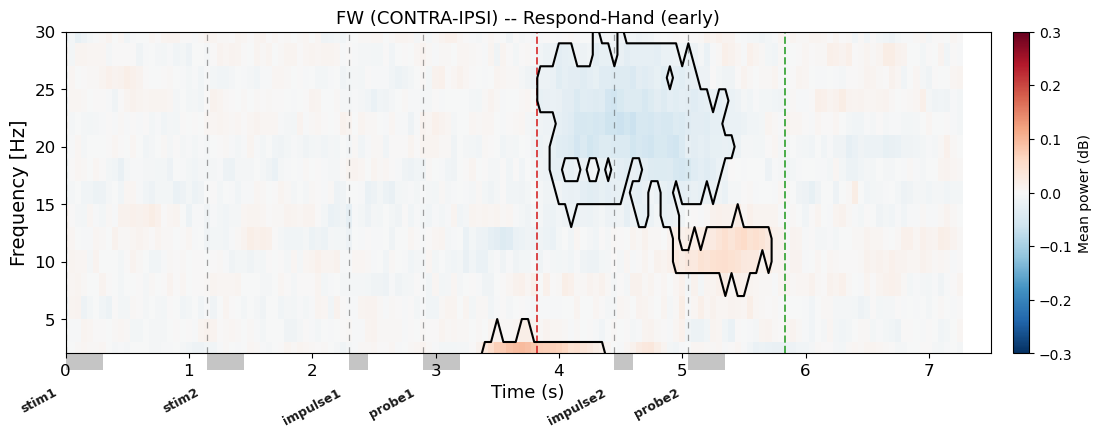

BW (CONTRA) -- Respond-Hand (early) 2D clusters:
2.00-28.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
BW (IPSI) -- Respond-Hand (early) 2D clusters:
2.00-28.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
BW (MID) -- Respond-Hand (early) 2D clusters:
2.00-30.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/bw_early_hand_tf_contra-ipsi-mid.png


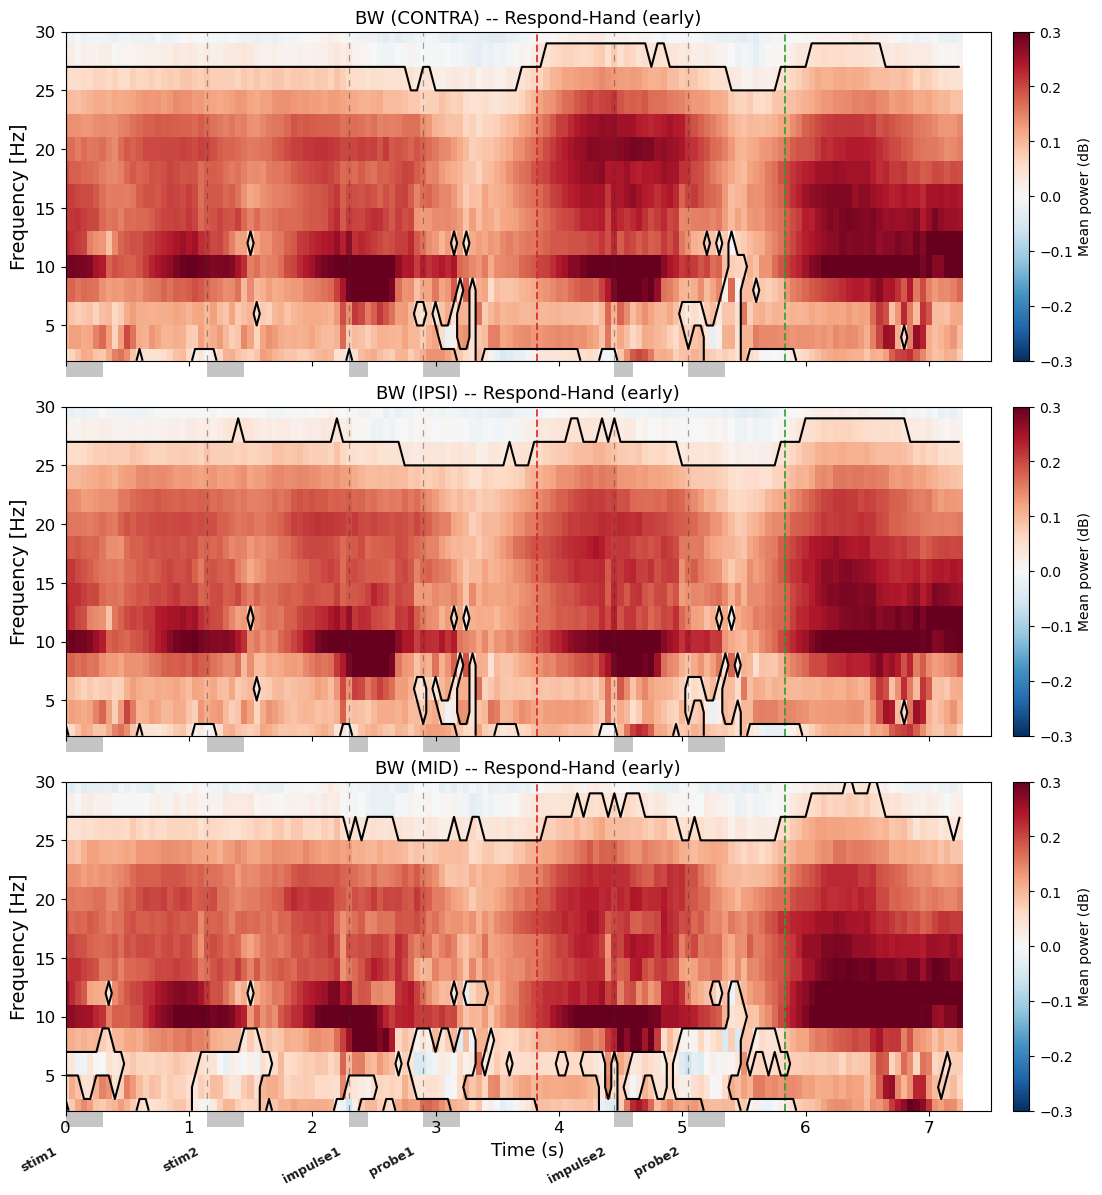

BW (CONTRA-IPSI) -- Respond-Hand (early) 2D clusters:
14.00-30.00 Hz, 3.95-5.60 s, p=0.0002 (significant)
2.00-2.00 Hz, 3.40-4.40 s, p=0.027 (significant)
8.00-14.00 Hz, 5.15-5.75 s, p=0.0452 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/bw_early_hand_tf.png


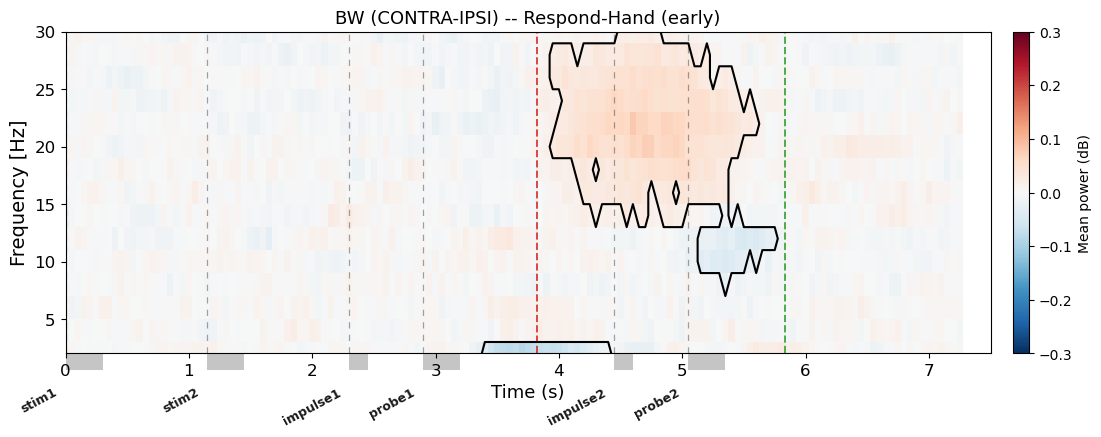

FW (CONTRA) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
FW (IPSI) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
FW (MID) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/fw_late_hand_tf_contra-ipsi-mid.png


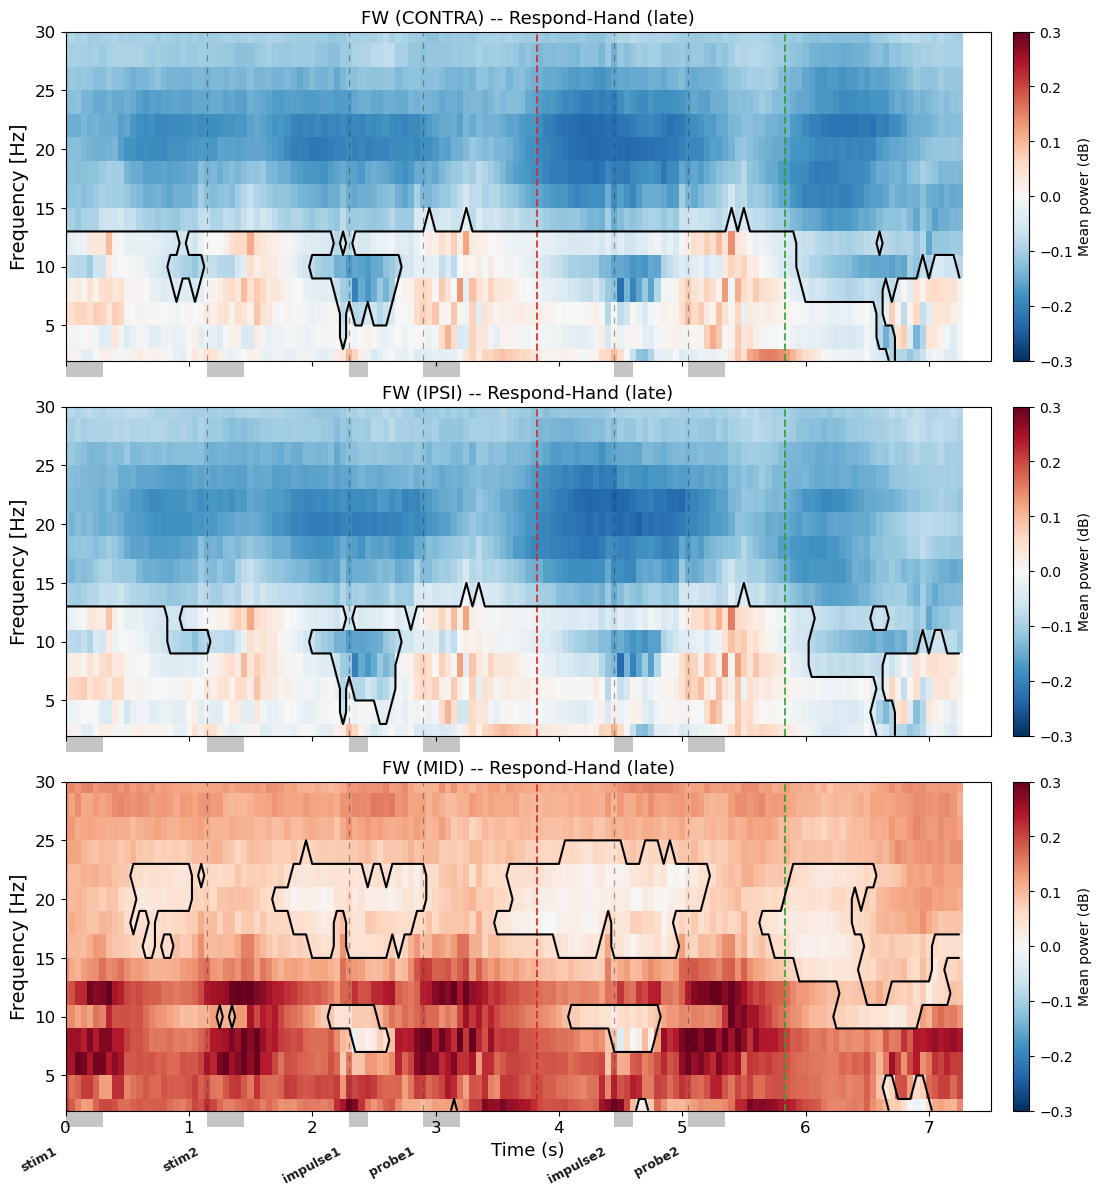

FW (CONTRA-IPSI) -- Respond-Hand (late) 2D clusters:
2.00-2.00 Hz, 5.55-6.35 s, p=0.0122 (significant)
6.00-12.00 Hz, 5.35-5.85 s, p=0.0326 (significant)
14.00-30.00 Hz, 6.00-7.25 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/fw_late_hand_tf.png


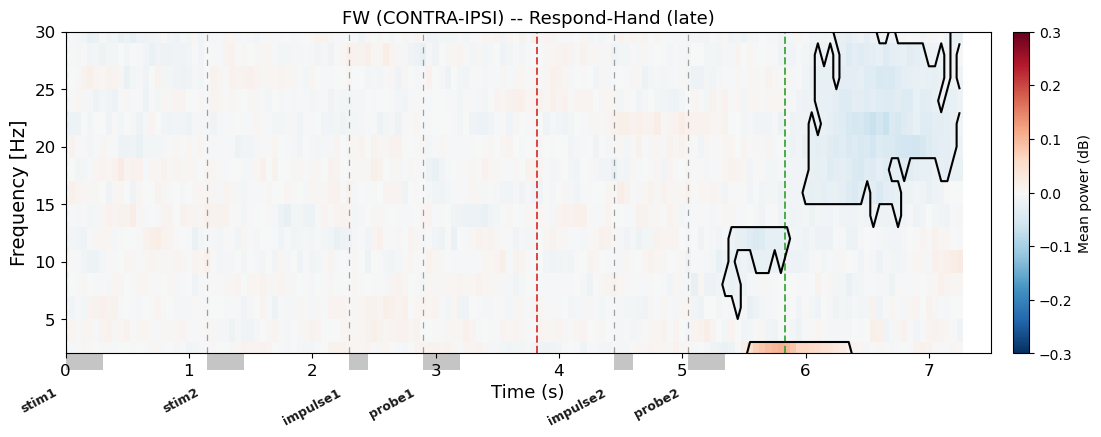

BW (CONTRA) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
BW (IPSI) -- Respond-Hand (late) 2D clusters:
2.00-28.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
BW (MID) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-7.25 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/bw_late_hand_tf_contra-ipsi-mid.png


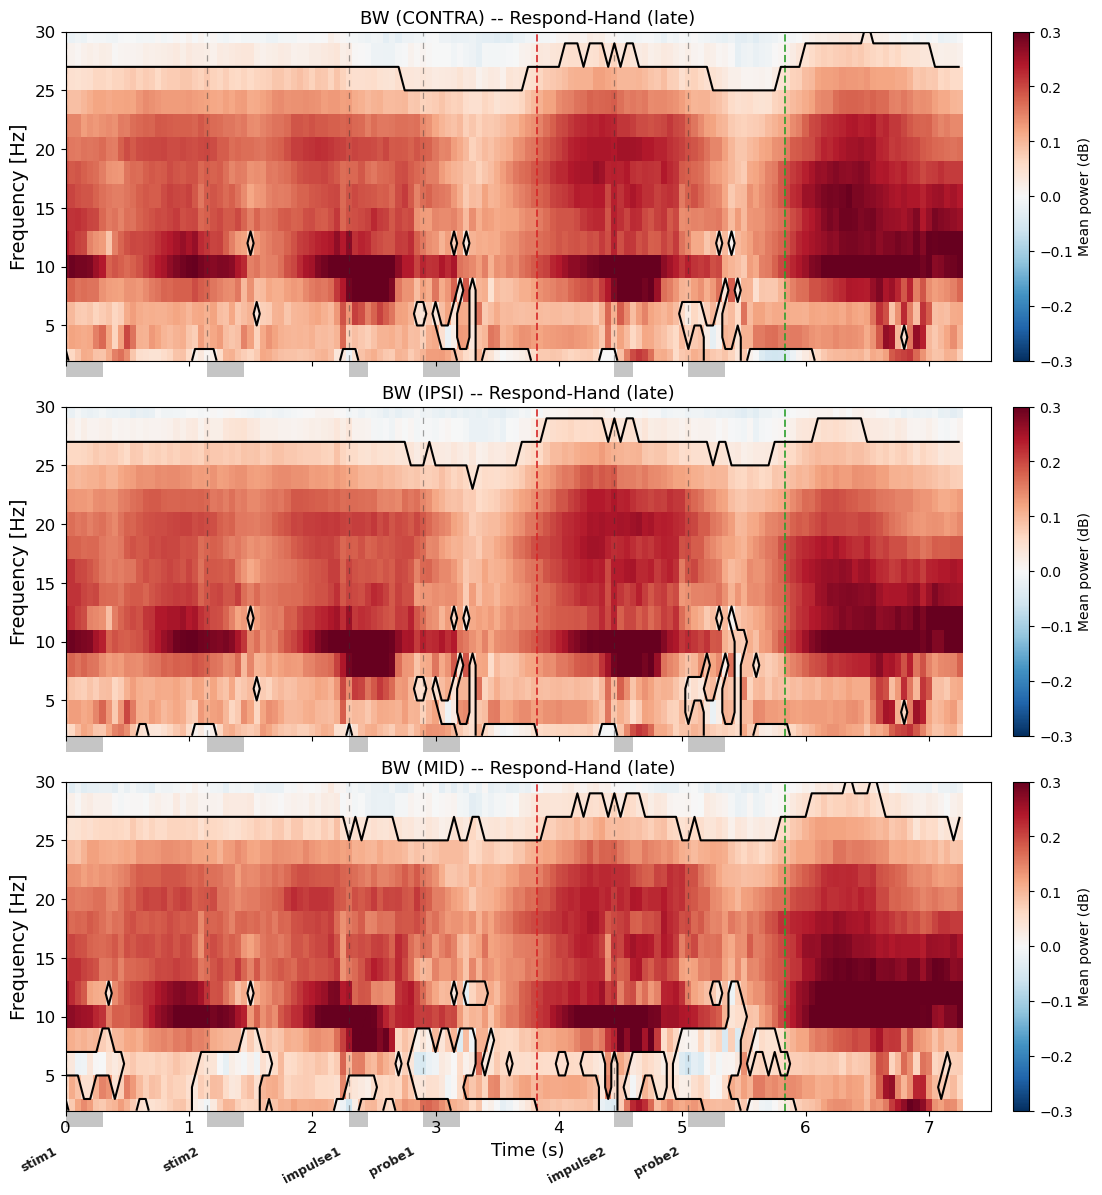

BW (CONTRA-IPSI) -- Respond-Hand (late) 2D clusters:
4.00-6.00 Hz, 5.55-6.00 s, p=0.0458 (significant)
14.00-30.00 Hz, 6.05-7.25 s, p=0.0002 (significant)
2.00-2.00 Hz, 5.50-6.40 s, p=0.0162 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/bw_late_hand_tf.png


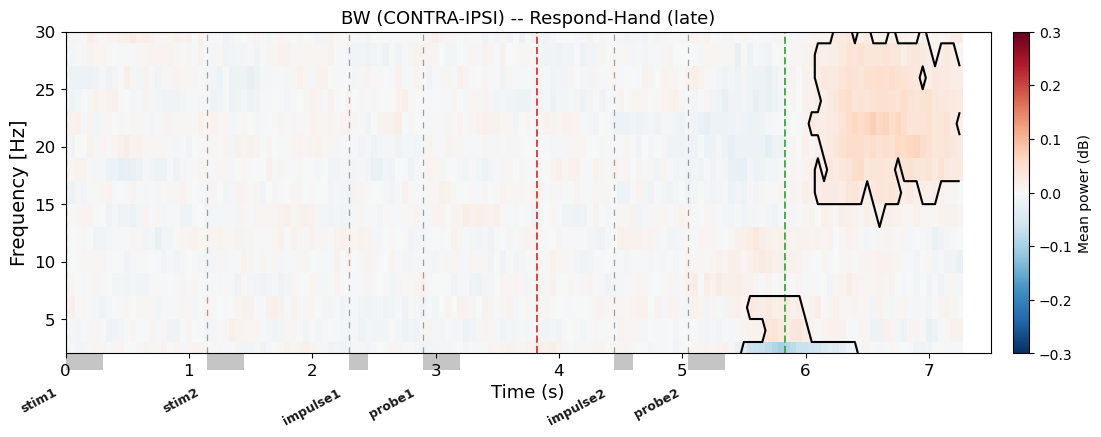

({'fw': {'diff': (<Figure size 1200x450 with 2 Axes>,
    <Axes: title={'center': 'FW (CONTRA-IPSI) -- Respond-Hand (late)'}, xlabel='Time (s)', ylabel='Frequency [Hz]'>,
    [{'p': 1.0,
      'significant': False,
      'freq_start_idx': 0,
      'freq_end_idx': 0,
      'time_start_idx': 46,
      'time_end_idx': 46},
     {'p': 1.0,
      'significant': False,
      'freq_start_idx': 0,
      'freq_end_idx': 0,
      'time_start_idx': 99,
      'time_end_idx': 99},
     {'p': 0.0122,
      'significant': True,
      'freq_start_idx': 0,
      'freq_end_idx': 0,
      'time_start_idx': 111,
      'time_end_idx': 127},
     {'p': 1.0,
      'significant': False,
      'freq_start_idx': 0,
      'freq_end_idx': 0,
      'time_start_idx': 139,
      'time_end_idx': 139},
     {'p': 0.998,
      'significant': False,
      'freq_start_idx': 1,
      'freq_end_idx': 2,
      'time_start_idx': 6,
      'time_end_idx': 7},
     {'p': 1.0,
      'significant': False,
      'freq_start_idx': 

In [5]:
# Contra - ipsi TF map，每个 measure 单独一张图。黑色轮廓是显著 cluster。
twplot.plot_tf_maps(by_subj, subj_ids, mode='hand', rt_type='early', trial_filter='all', measure=MEASURES, baseline_correct=BASELINE_CORRECT, bl0=BL0, bl1=BL1, t_stop=7.5, fmax=30, max_rt=MAX_RT, vabs=TF_VABS, n_perm=5000, **LINE_KW, **TRIAL_CLEAN_KW)
twplot.plot_tf_maps(by_subj, subj_ids, mode='hand', rt_type='late',  trial_filter='all', measure=MEASURES, baseline_correct=BASELINE_CORRECT, bl0=BL0, bl1=BL1, t_stop=7.5, fmax=30, max_rt=MAX_RT, vabs=TF_VABS, n_perm=5000, **LINE_KW, **TRIAL_CLEAN_KW)

Respond-Hand (early) | fw | Theta (2-6 Hz):
3.45-4.25s, p=0.0002 (significant)
Respond-Hand (early) | fw | Alpha (8-12 Hz):
4.95-5.70s, p=0.0002 (significant)
3.35-3.60s, p=0.0288 (significant)
Respond-Hand (early) | fw | Beta (14-30 Hz):
3.85-5.30s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/fw_early_hand_band.png


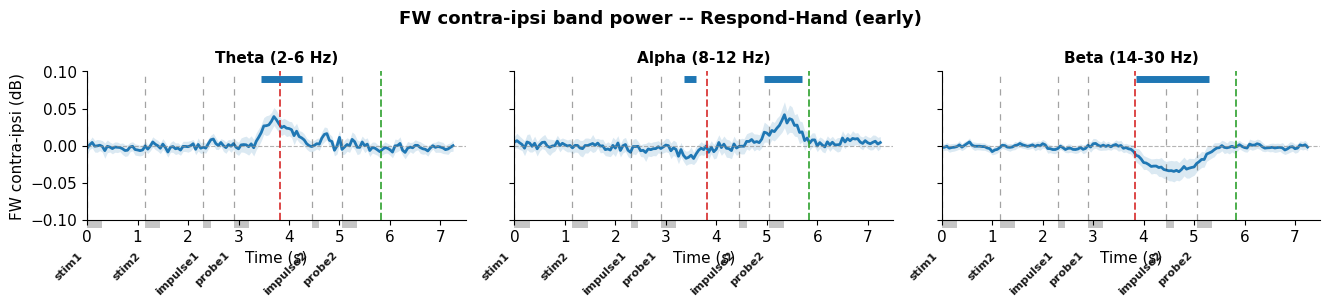

Respond-Hand (early) | bw | Theta (2-6 Hz):
3.65-4.05s, p=0.007 (significant)
Respond-Hand (early) | bw | Alpha (8-12 Hz):
5.15-5.70s, p=0.0006 (significant)
Respond-Hand (early) | bw | Beta (14-30 Hz):
3.95-5.50s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/bw_early_hand_band.png


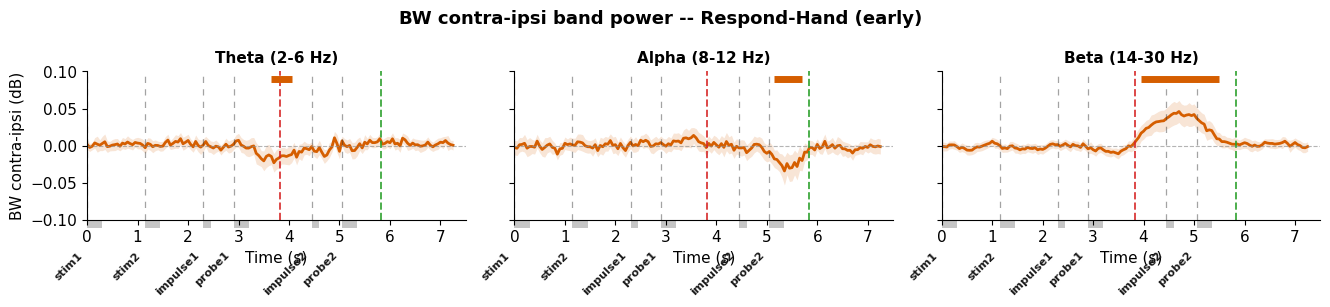

Respond-Hand (late) | fw | Theta (2-6 Hz):
2.45-2.60s, p=0.0478 (significant)
5.60-6.20s, p=0.0002 (significant)
Respond-Hand (late) | fw | Alpha (8-12 Hz):
5.25-5.85s, p=0.0004 (significant)
Respond-Hand (late) | fw | Beta (14-30 Hz):
6.00-7.25s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/fw_late_hand_band.png


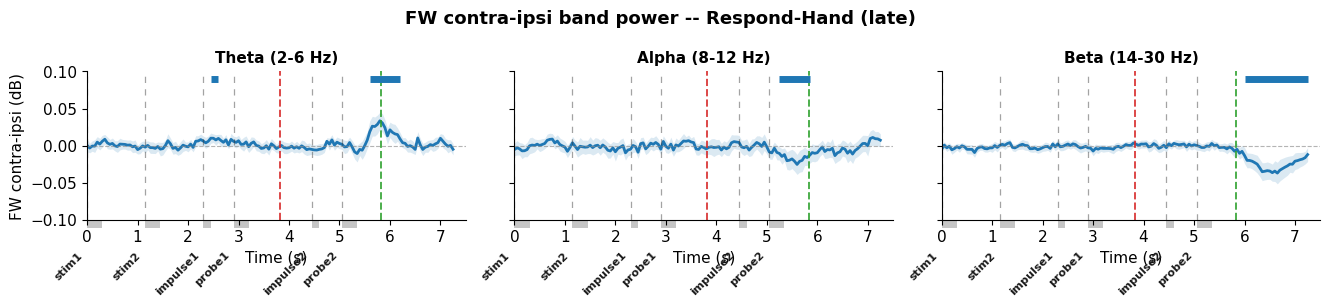

Respond-Hand (late) | bw | Theta (2-6 Hz):
No significant clusters found.
Respond-Hand (late) | bw | Alpha (8-12 Hz):
No significant clusters found.
Respond-Hand (late) | bw | Beta (14-30 Hz):
6.05-7.25s, p=0.0002 (significant)
5.25-5.70s, p=0.0312 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/no-bl/all/bw_late_hand_band.png


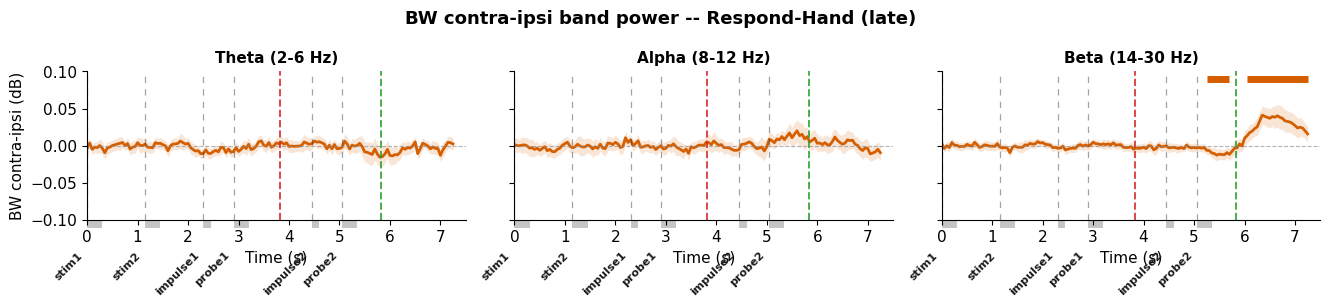

In [6]:
# Contra - ipsi band time course。每个 measure 单独一张 1x3 图（Theta / Alpha / Beta）。
# 仍然分开画 early / late，两张图都在每个子图上标上对应的 RT 虚线。
for RT_TYPE in ['early', 'late']:
    twplot.plot_band_timeseries(
        by_subj, subj_ids,
        mode='hand',
        rt_type=RT_TYPE,
        trial_filter='all',
        measure=MEASURES,
        baseline_correct=BASELINE_CORRECT,
        bl0=BL0,
        bl1=BL1,
        t_stop=7.5,
        max_rt=MAX_RT,
        split_measures=True,
        n_perm=5000,
        **LINE_KW,
        **TRIAL_CLEAN_KW,
    )

## Fast / Slow RT Analysis

下面这段代码会按 `early` / `late` RT 计算 fast/slow 试次，并绘制 fast vs slow 曲线。

In [7]:
# MODE = 'hand'
# for RT_TYPE in ['early', 'late']:
#     freq_bands = [(2, 6), (8, 12), (14, 30)]
#     result = twplot.compute_fast_slow(
#         by_subj, subj_ids,
#         mode=MODE,
#         rt_type=RT_TYPE,
#         baseline_correct=BASELINE_CORRECT,
#         bl0=BL0, bl1=BL1,
#         trial_filter='all',
#         max_rt=MAX_RT,
#         freq_bands=freq_bands,
#         **TRIAL_CLEAN_KW,
#     )
#     twplot.plot_fast_slow(
#         *result,
#         freq_bands=freq_bands,
#         save=True,
#         save_dir=twplot.FIG_DIR,
#     )

fw Theta (2-6 Hz), line-power, hand-early, all, max_rt=1.55:
No significant clusters found.
fw Alpha (8-12 Hz), line-power, hand-early, all, max_rt=1.55:
No significant clusters found.
fw Beta (14-30 Hz), line-power, hand-early, all, max_rt=1.55:
0.00-7.25s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/line_power_bands_fw_hand-early_all.png


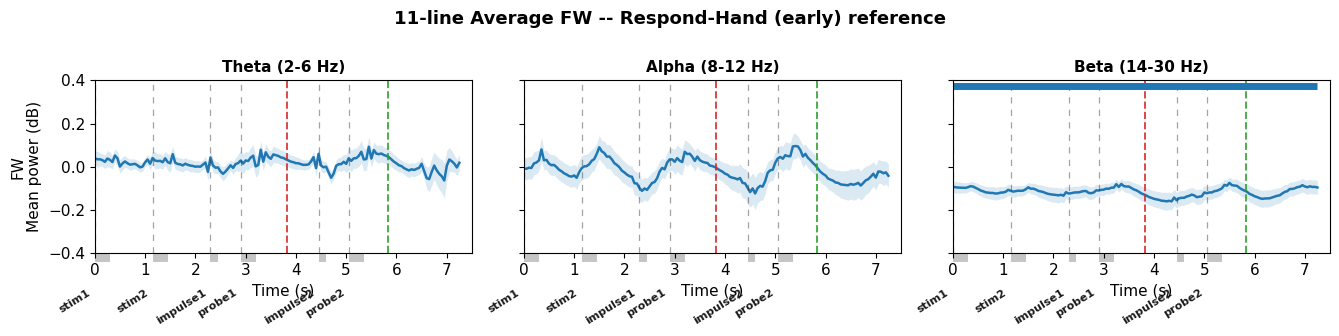

bw Theta (2-6 Hz), line-power, hand-early, all, max_rt=1.55:
0.00-5.25s, p=0.0002 (significant)
5.35-7.25s, p=0.0006 (significant)
bw Alpha (8-12 Hz), line-power, hand-early, all, max_rt=1.55:
0.00-7.25s, p=0.0002 (significant)
bw Beta (14-30 Hz), line-power, hand-early, all, max_rt=1.55:
0.00-7.25s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/line_power_bands_bw_hand-early_all.png


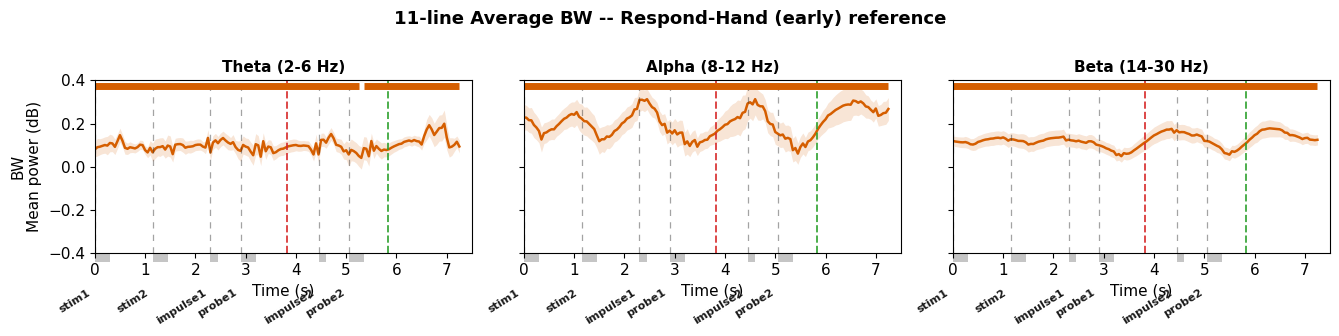

In [8]:
# 旧的 all-measures band helper 现在不默认跑，避免和上面的 band 图重复。
# 如需单独重画 all-trials 的 11-line mean TW power，可以取消下面两行注释。
twplot.plot_line_power_bands(by_subj, subj_ids, rt_type='early', trial_filter='all', measure=MEASURES, baseline_correct=BASELINE_CORRECT, bl0=BL0, bl1=BL1, line_idx=LINE_IDX, max_rt=MAX_RT, n_perm=5000, **TRIAL_CLEAN_KW);
# twplot.plot_line_power_bands(by_subj, subj_ids, rt_type='late',  trial_filter='all', measure=MEASURES, baseline_correct=BASELINE_CORRECT, bl0=BL0, bl1=BL1, line_idx=LINE_IDX, max_rt=MAX_RT, n_perm=5000, **TRIAL_CLEAN_KW);

fw Theta (2-6 Hz), line-power fixed-random, hand-late, max_rt=1.55:
No significant clusters found.
fw Alpha (8-12 Hz), line-power fixed-random, hand-late, max_rt=1.55:
No significant clusters found.
fw Beta (14-30 Hz), line-power fixed-random, hand-late, max_rt=1.55:
No significant clusters found.
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/fw_all.png


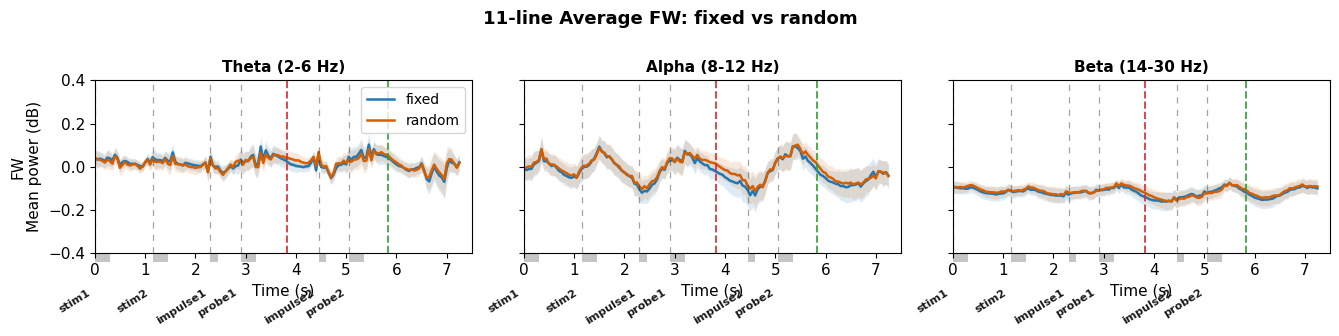

bw Theta (2-6 Hz), line-power fixed-random, hand-late, max_rt=1.55:
No significant clusters found.
bw Alpha (8-12 Hz), line-power fixed-random, hand-late, max_rt=1.55:
No significant clusters found.
bw Beta (14-30 Hz), line-power fixed-random, hand-late, max_rt=1.55:
3.30-4.15s, p=0.0058 (significant)
[saved] /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft/bw_all.png


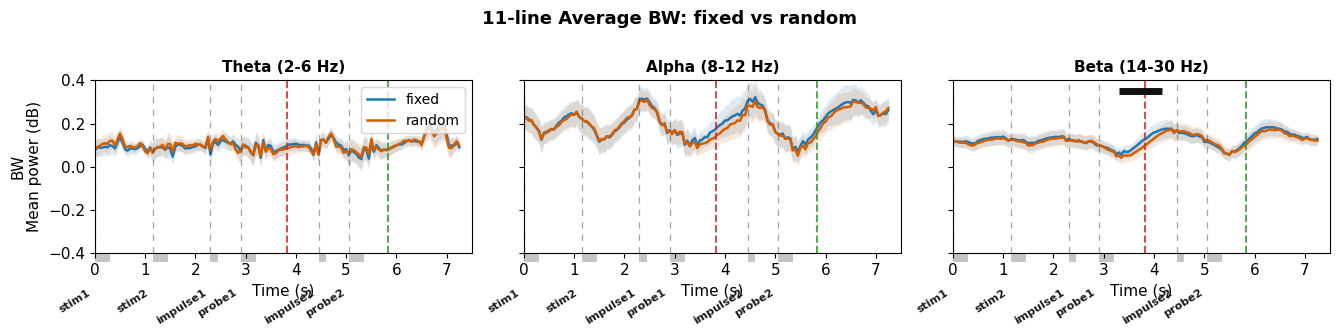

({'fw': (<Figure size 1350x420 with 3 Axes>,
   array([<Axes: title={'center': 'Theta (2-6 Hz)'}, xlabel='Time (s)', ylabel='FW\nMean power (dB)'>,
          <Axes: title={'center': 'Alpha (8-12 Hz)'}, xlabel='Time (s)'>,
          <Axes: title={'center': 'Beta (14-30 Hz)'}, xlabel='Time (s)'>],
         dtype=object)),
  'bw': (<Figure size 1350x420 with 3 Axes>,
   array([<Axes: title={'center': 'Theta (2-6 Hz)'}, xlabel='Time (s)', ylabel='BW\nMean power (dB)'>,
          <Axes: title={'center': 'Alpha (8-12 Hz)'}, xlabel='Time (s)'>,
          <Axes: title={'center': 'Beta (14-30 Hz)'}, xlabel='Time (s)'>],
         dtype=object))},
 {'fixed': {'fw': array([[[-0.02939312, -0.09451711, -0.10091678, ...,  0.14152644,
             0.09651723,  0.15999151],
           [ 0.01522616, -0.02856027,  0.07659806, ...,  0.16043758,
            -0.10941703,  0.03062341],
           [-0.02426081,  0.01200415,  0.0843922 , ...,  0.2546104 ,
             0.0350869 , -0.08551128],
           ...,


In [9]:
# Fixed vs random condition 对比：11 条 electrode lines 平均后的 TW power。
# 每个 measure 会输出一张 1x3 图；两条线分别是 fixed 和 random，黑色显著条是 paired fixed-random cluster。
# twplot.plot_fixed_random_line_power_bands(
#     by_subj,
#     subj_ids,
#     rt_type='early',
#     measure=MEASURES,
#     baseline_correct=BASELINE_CORRECT,
#     bl0=BL0,
#     bl1=BL1,
#     line_idx=LINE_IDX,
#     max_rt=MAX_RT,
#     n_perm=5000,
#     **TRIAL_CLEAN_KW,
# )
twplot.plot_fixed_random_line_power_bands(
    by_subj,
    subj_ids,
    rt_type='late',
    measure=MEASURES,
    baseline_correct=BASELINE_CORRECT,
    bl0=BL0,
    bl1=BL1,
    line_idx=LINE_IDX,
    max_rt=MAX_RT,
    n_perm=5000,
    **TRIAL_CLEAN_KW,
)

In [10]:
print(f'Figures saved to: {twplot.FIG_DIR}')


Figures saved to: /home/dilay/project2/tw/results/mingmin_linux/mingmin_fft
